# Sentiment analysis based on IMDb reviews 
#### Kinga Heda, Bartosz Łuksza, Arkadiusz Kijaczek

Sentiment analysis helps in finding the emotional tone of a sentence. In this project ...

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import contractions
from IPython.display import display
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_recall_fscore_support
from pathlib import Path
import mlflow
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# required once
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\admmass\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admmass\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admmass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admmass\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admmass\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [39]:
mlflow.set_tracking_uri(Path("./mlruns").absolute().as_uri())
mlflow.set_experiment("imdb-sentiment")

mlflow.sklearn.autolog(
    log_models=True,
    log_input_examples=False,
    log_model_signatures=False,
    silent=True,
)

print("MLflow tracking URI :", mlflow.get_tracking_uri())
print("Active experiment   :", mlflow.get_experiment_by_name("imdb-sentiment").name)

c:\Users\admmass\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/04 21:56:23 INFO mlflow.tracking.fluent: Experiment with name 'imdb-sentiment' does not exist. Creating a new experiment.


MLflow tracking URI : file:///c:/Users/admmass/Desktop/magisterka/ml/Sentiment-analysis/mlruns
Active experiment   : imdb-sentiment


---
## 1. Data
The dataset used in this project is the Large Movie Review Dataset, publicly available from Stanford AI Lab at: http://ai.stanford.edu/~amaas/data/sentiment/. It is a binary sentiment classification benchmark based on 50,000 movie reviews collected from IMDb. The dataset is evenly split into 25,000 training and 25,000 testing samples.

Each labeled review is classified as either positive or negative based on its rating: reviews with scores ≥ 7 are considered positive, while those with scores ≤ 4 are labeled negative. Neutral reviews are excluded, making the task both challenging and clearly defined.

### Dataset Overview

| Attribute                | Value                         |
|--------------------------|-------------------------------|
| Total reviews            | 50,000                        |
| Training set             | 25,000                        |
| Test set                 | 25,000                        |
| Positive reviews         | 25,000 (ratings ≥ 7)          |
| Negative reviews         | 25,000 (ratings ≤ 4)          |
| Neutral reviews          | Excluded (ratings 5–6)        |
| Max reviews per movie    | 30                            |

In [13]:
def load_imdb_data(data_dir):
    rows = []
    
    for split in ['train', 'test']:
        for sentiment in ['pos', 'neg']:
            path = os.path.join(data_dir, split, sentiment)
            
            for file in os.listdir(path):
                file_path = os.path.join(path, file)
                
                review_id, rating = file.replace(".txt", "").split("_")
                
                with open(file_path, 'r', encoding='utf-8') as f:
                    review = f.read()
                    
                    rows.append({
                        "review_id": int(review_id),
                        "split": split,
                        "rating": int(rating),
                        "text": review,
                        "sentiment": sentiment,
                        "sentiment_label": 1 if sentiment == 'pos' else 0,
                        "movie_id": None  
                    })
    
    df = pd.DataFrame(rows)
    return df

data_dir = "C:/Users/admmass\Desktop/magisterka/ml/sentiment_analysis/aclImdb_v1 (1)/aclImdb"

df = load_imdb_data(data_dir)
df_train = df[df['split'] == 'train'].copy()
df_test = df[df['split'] == 'test'].copy()
df.head()

,review_id,split,rating,text,sentiment,sentiment_label,movie_id
0,0,train,9,Bromwell High is a cartoon comedy. It ran at t...,pos,1,None
1,10000,train,8,Homelessness (or Houselessness as George Carli...,pos,1,None
2,10001,train,10,Brilliant over-acting by Lesley Ann Warren. Be...,pos,1,None
3,10002,train,7,This is easily the most underrated film inn th...,pos,1,None
4,10003,train,8,This is not the typical Mel Brooks film. It wa...,pos,1,None


---
## 2. Exploratory Data Analysis (EDA)

In [14]:
print('\n--- Missing Values: ---')
print(f"{df.isnull().sum()}")
print('\n--- Duplicates: ---')
print(f"{df.duplicated().sum()}")

df['review_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['avg_word_length'] = df['review_length'] / df['word_count']

print('\n--- Statitics summary: ---')
print(df[['rating', 'review_length', 'word_count', 'avg_word_length']].describe())
print("\n--- Distribution by Split & Sentiment ---")
print(df.groupby(['split', 'sentiment']).size().unstack(fill_value=0))
print("\n--- Rating Distribution ---")
print(df['rating'].value_counts().sort_index())


--- Missing Values: ---
review_id              0
split                  0
rating                 0
text                   0
sentiment              0
sentiment_label        0
movie_id           50000
dtype: int64

--- Duplicates: ---
0

--- Statitics summary: ---
             rating  review_length    word_count  avg_word_length
count  50000.000000   50000.000000  50000.000000     50000.000000
mean       5.495340    1309.431020    231.156940         5.634164
std        3.478721     989.728014    171.343997         0.340905
min        1.000000      32.000000      4.000000         2.236486
25%        2.000000     699.000000    126.000000         5.411392
50%        5.500000     970.000000    173.000000         5.620934
75%        9.000000    1590.250000    280.000000         5.841730
max       10.000000   13704.000000   2470.000000        13.272727

--- Distribution by Split & Sentiment ---
sentiment    neg    pos
split                  
test       12500  12500
train      12500  12500

--

C:\Users\admmass\AppData\Local\Temp\ipykernel_23340\3017421939.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='word_count',


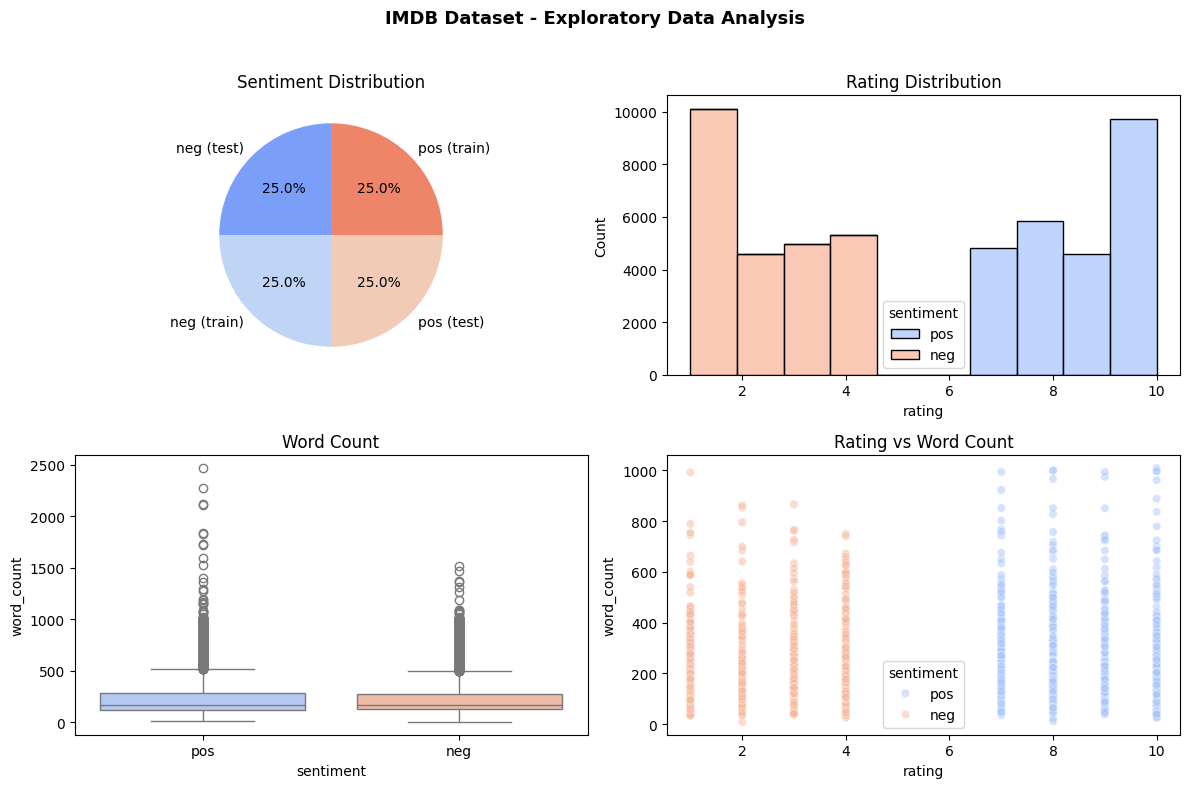

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('IMDB Dataset - Exploratory Data Analysis', fontsize=13, fontweight='bold')

palette = sns.color_palette("coolwarm", 2)
counts = df.groupby(['sentiment','split']).size()
labels = [f"{s} ({sp})" for s, sp in counts.index]

# Plot 1: Sentiment distribution
axes[0,0].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90,
              colors=sns.color_palette("coolwarm", len(counts)))
axes[0,0].set_title('Sentiment Distribution')

# Plot 2: Rating distribution
sns.histplot(data=df, x='rating', hue='sentiment', multiple='stack',
             ax=axes[0,1], palette=palette, bins=10)
axes[0,1].set_title('Rating Distribution')

# Plot 3: Boxplot - Word count by sentiment
sns.boxplot(data=df, x='sentiment', y='word_count',
            ax=axes[1,0], palette=palette)
axes[1,0].set_title('Word Count')

# Plot 4: Scatter - Rating vs Word count
sample = df.sample(n=2000, random_state=42)
sns.scatterplot(data=sample, x='rating', y='word_count',
                hue='sentiment', alpha=0.5,
                ax=axes[1,1], palette=palette)
axes[1,1].set_title('Rating vs Word Count')

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('eda_plots.png', dpi=150)
plt.show()


In [16]:
print('\n--- Outliers detection: ---')
for col in ['review_length', 'word_count']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({100*len(outliers)/len(df):.2f}%)")

print('\n--- Correlation matrix: ---')
corr_cols = ['rating', 'sentiment_label', 'review_length', 'word_count', 'avg_word_length']
print(df[corr_cols].corr().round(3))


--- Outliers detection: ---
review_length: 3737 outliers (7.47%)
word_count: 3708 outliers (7.42%)

--- Correlation matrix: ---
                 rating  sentiment_label  review_length  word_count  \
rating            1.000            0.942          0.013       0.008   
sentiment_label   0.942            1.000          0.016       0.010   
review_length     0.013            0.016          1.000       0.997   
word_count        0.008            0.010          0.997       1.000   
avg_word_length   0.054            0.050          0.183       0.121   

                 avg_word_length  
rating                     0.054  
sentiment_label            0.050  
review_length              0.183  
word_count                 0.121  
avg_word_length            1.000  


**Conclusions:**

1. Dataset size: 50,000 reviews (25k train, 25k test), perfectly balanced.
2. Missing data: None - all fields complete.
3. Class balance: Equal pos/neg split in both train and test sets.
4. Rating pattern: Negative reviews (1-4), Positive reviews (7-10). Ratings 5-6 are excluded.
5. Text length: 
   - Mean ~1,300 characters / ~230 words per review.
   - Positive reviews slightly longer on average.
6. Outliers: ~5-8% of reviews are unusually long (>600 words) but there is no strong correlation between review length and sentiment.
   Length alone won't predict sentiment well - content matters.

---
## 3. Preprocessing
Defined two text preprocessing functions used for cleaning and preparing raw text data for diffrent tasks.

- clean_minimal(text) performs basic cleaning by removing HTML tags, URLs, and extra whitespace, keeping the text largely unchanged otherwise.
- clean_full(text) applies a more advanced NLP pipeline: it removes HTML and URLs, expands contractions, filters out special characters and numbers, converts text to lowercase, tokenizes it, removes stopwords (while preserving important negations like “not” or “never”), lemmatizes words to their base form, and removes very short tokens.

In [17]:
def clean_minimal(text):
    text = re.sub(r'<[^>]+>', ' ', text) # Remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text) # Remove URLs
    text = re.sub(r'\s+', ' ', text).strip() # Normalize whitespace
    return text

def clean_full(text):
    text = re.sub(r'<[^>]+>', ' ', text) # Remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text) # Remove URLs
    text = contractions.fix(text)  # Expand contractions
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Remove special characters and numbers 
    text = text.lower() # Lowercase
    tokens = word_tokenize(text) # Tokenize
    stop_words = set(stopwords.words('english')) # Remove stopwords
    stop_words -= {'not', 'no', 'nor', 'never', "don't", "doesn't", "didn't",
              "won't", "wouldn't", "can't", "couldn't", "shouldn't",
              "isn't", "aren't", "wasn't", "weren't"}
    tokens = [word for word in tokens if word not in stop_words]
    lemmatizer = WordNetLemmatizer() # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    tokens = [word for word in tokens if len(word) > 1] # Remove short tokens (length < 2)
    return ' '.join(tokens)

In [18]:
df['text_raw'] = df['text'].apply(clean_minimal)
df['text_clean'] = df['text'].apply(clean_full)
    
df['text_length_original'] = df['text'].apply(len)
df['text_length_raw'] = df['text_raw'].apply(len)
df['text_length_clean'] = df['text_clean'].apply(len)
df['word_count_clean'] = df['text_clean'].apply(lambda x: len(x.split()))

In [19]:
print('\n---------- Example: ---------')
sample = df.iloc[10]
print(f"\nORIGINAL:\n{sample['text']}...")
print(f"\nTEXT_RAW:\n{sample['text_raw']}...")
print(f"\nTEXT_CLEAN:\n{sample['text_clean']}...")

print('\n---------- Statistics: ----------')
display(df[['text_length_original', 'text_length_raw',
            'text_length_clean', 'word_count_clean']].describe().round(2))

df.head()


---------- Example: ---------

ORIGINAL:
When I first read Armistead Maupins story I was taken in by the human drama displayed by Gabriel No one and those he cares about and loves. That being said, we have now been given the film version of an excellent story and are expected to see past the gloss of Hollywood...<br /><br />Writer Armistead Maupin and director Patrick Stettner have truly succeeded! <br /><br />With just the right amount of restraint Robin Williams captures the fragile essence of Gabriel and lets us see his struggle with issues of trust both in his personnel life(Jess) and the world around him(Donna).<br /><br />As we are introduced to the players in this drama we are reminded that nothing is ever as it seems and that the smallest event can change our lives irrevocably. The request to review a book written by a young man turns into a life changing event that helps Gabriel find the strength within himself to carry on and move forward.<br /><br />It's to bad that most pe

,text_length_original,text_length_raw,text_length_clean,word_count_clean
count,50000.00,50000.00,50000.00,50000.00
mean,1309.43,1286.76,811.98,120.83
std,989.73,972.37,627.08,90.98
min,32.00,32.00,17.00,3.00
25%,699.00,690.00,425.00,65.00
50%,970.00,954.00,597.00,90.00
75%,1590.25,1561.00,987.00,147.00
max,13704.00,13593.00,9114.00,1411.00


,review_id,split,rating,text,sentiment,sentiment_label,movie_id,review_length,word_count,avg_word_length,text_raw,text_clean,text_length_original,text_length_raw,text_length_clean,word_count_clean
0,0,train,9,Bromwell High is a cartoon comedy. It ran at t...,pos,1,None,806,140,5.757143,Bromwell High is a cartoon comedy. It ran at t...,bromwell high cartoon comedy ran time program ...,806,806,493,70
1,10000,train,8,Homelessness (or Houselessness as George Carli...,pos,1,None,2366,428,5.528037,Homelessness (or Houselessness as George Carli...,homelessness houselessness george carlin state...,2366,2322,1378,208
2,10001,train,10,Brilliant over-acting by Lesley Ann Warren. Be...,pos,1,None,841,147,5.721088,Brilliant over-acting by Lesley Ann Warren. Be...,brilliant acting lesley ann warren best dramat...,841,841,558,84
3,10002,train,7,This is easily the most underrated film inn th...,pos,1,None,663,124,5.346774,This is easily the most underrated film inn th...,easily underrated film inn brook cannon sure f...,663,663,422,66
4,10003,train,8,This is not the typical Mel Brooks film. It wa...,pos,1,None,647,120,5.391667,This is not the typical Mel Brooks film. It wa...,not typical mel brook film much le slapstick m...,647,647,347,54


---
## 4. VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analyzer designed for English. It outputs four scores (`neg`, `neu`, `pos`, `compound`). We use the **compound** score (range -1 to +1) as the overall polarity.

For IMDb (binary labels), we apply a simple rule:
- `compound >= 0`: positive
- `compound < 0`: negative

Below, VADER is evaluated on `text_raw` (lightly normalized text).

In [22]:
sia = SentimentIntensityAnalyzer()

def vader_scores(text: str):
    return sia.polarity_scores(text)


def vader_compound(text: str) -> float:
    return vader_scores(text)["compound"]


def vader_pred_from_compound(compound: float) -> int:
    return 1 if compound >= 0 else 0

# Run VADER on text_raw
df_test['text_raw'] = df['text'].apply(clean_minimal)
df_test['text_raw'] = df_test['text_raw'].astype(str)

df_test["vader_compound"] = df_test['text_raw'].apply(vader_compound)
df_test["vader_pred"] = df_test["vader_compound"].apply(vader_pred_from_compound)

y_true = df_test["sentiment_label"]
y_pred = df_test["vader_pred"]

example_text = df_test.iloc[10]['text_raw']
example_scores = vader_scores(example_text)
print("Example: text_raw (first 200 chars)")
print(example_text[:200] + ("..." if len(example_text) > 200 else ""))
print("\nVADER scores:")
print(example_scores)
print("Predicted label:", "positive" if vader_pred_from_compound(example_scores["compound"]) == 1 else "negative")

Example: text_raw (first 200 chars)
I loved this movie from beginning to end.I am a musician and i let drugs get in the way of my some of the things i used to love(skateboarding,drawing) but my friends were always there for me.Music was...

VADER scores:
{'neg': 0.071, 'neu': 0.744, 'pos': 0.185, 'compound': 0.988}
Predicted label: positive


In [23]:
accuracy = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_pos = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_pos = 2 * (precision_pos * recall_pos) / (precision_pos + recall_pos) if (precision_pos + recall_pos) > 0 else 0

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (pos): {precision_pos:.4f} | Recall (pos): {recall_pos:.4f} | F1 (pos): {f1_pos:.4f}")
print("\nConfusion matrix [[TN FP],[FN TP]]:")
print(cm)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

Accuracy: 0.6990 (69.90%)
Precision (pos): 0.6503 | Recall (pos): 0.8610 | F1 (pos): 0.7409

Confusion matrix [[TN FP],[FN TP]]:
[[ 6711  5789]
 [ 1737 10763]]

Classification report:
              precision    recall  f1-score   support

    negative       0.79      0.54      0.64     12500
    positive       0.65      0.86      0.74     12500

    accuracy                           0.70     25000
   macro avg       0.72      0.70      0.69     25000
weighted avg       0.72      0.70      0.69     25000



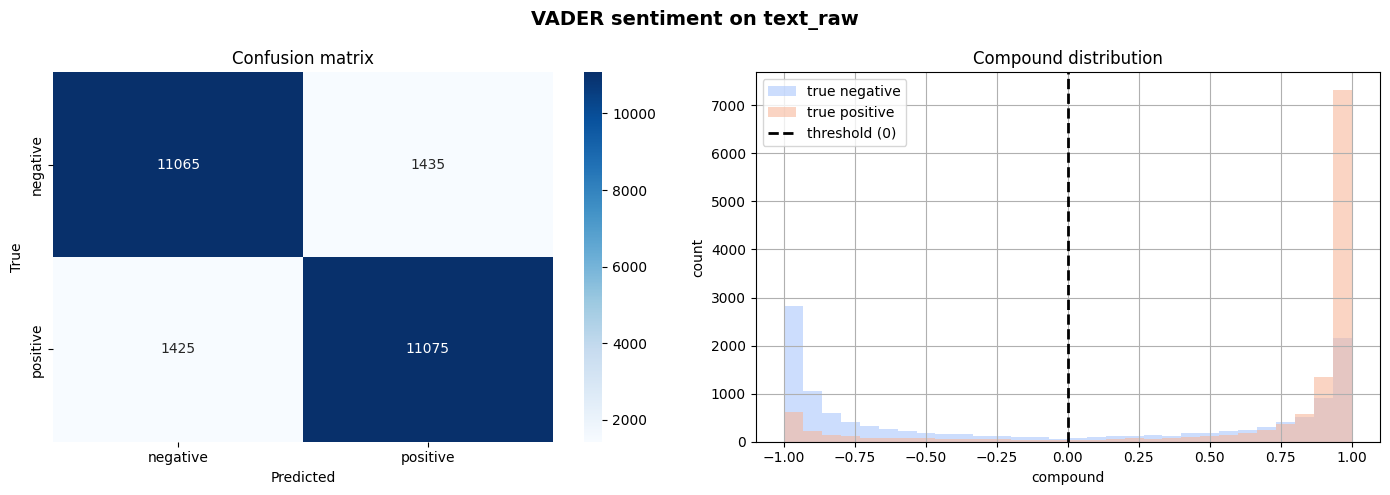


Errors closest to the threshold (|compound| smallest):


,vader_compound,sentiment_label,vader_pred,text_raw
44607,0.0,0,1,Primary plot!Primary direction!Poor interpreta...
39737,0.0,0,1,Ten minutes of people spewing gallons of pink ...
48467,0.0,0,1,"More suspenseful, more subtle, much, much more..."
48329,-0.0,0,1,This movie is a gay love story disguised as a ...
45048,-0.0,0,1,Pumpkinhead was in itself a decent 80s horror ...


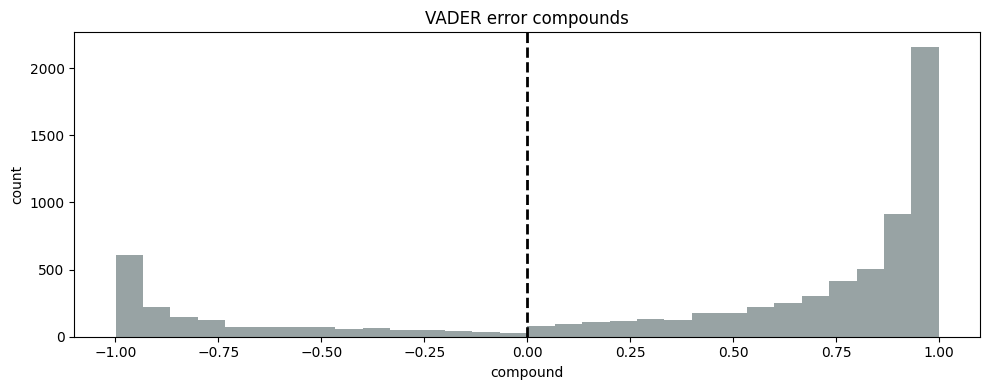

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("VADER sentiment on text_raw", fontsize=14, fontweight="bold")

ax = axes[0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

ax = axes[1]
df_test[df_test["sentiment_label"] == 0]["vader_compound"].hist(
    bins=30, alpha=0.6, label="true negative", color=(0.6673, 0.7792, 0.9930), ax=ax
)
df_test[df_test["sentiment_label"] == 1]["vader_compound"].hist(
    bins=30, alpha=0.6, label="true positive", color=(0.9682, 0.7208, 0.6123), ax=ax
)
ax.axvline(x=0, color="black", linestyle="--", linewidth=2, label="threshold (0)")
ax.set_xlabel("compound")
ax.set_ylabel("count")
ax.set_title("Compound distribution")
ax.legend()

plt.tight_layout()
plt.savefig("vader_analysis_results.png", dpi=150, bbox_inches="tight")
plt.show()

errors = df_test[df_test["sentiment_label"] != df_test["vader_pred"]].copy()
if len(errors) > 0:
    errors["abs_compound"] = errors["vader_compound"].abs()
    print("\nErrors closest to the threshold (|compound| smallest):")
    display(
        errors.sort_values("abs_compound")[["vader_compound", "sentiment_label", "vader_pred", "text_raw"]]
        .head(5)
    )

plt.figure(figsize=(10, 4))
plt.hist(errors["vader_compound"], bins=30, color="#7f8c8d", alpha=0.8)
plt.axvline(x=0, color="black", linestyle="--", linewidth=2)
plt.title("VADER error compounds")
plt.xlabel("compound")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("vader_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Logistic Regression 

A strong classical baseline for sentiment analysis is Logistic Regression* trained on TF‑IDF features.

- Input: `text_clean`
- Features: `TfidfVectorizer`
- Model: `LogisticRegression`

Run ID: 4f8257b3ad2543f9b802831f1fdeae42
Accuracy: 0.8856 (88.56%)
Precision (pos): 0.8853 | Recall (pos): 0.8860 | F1 (pos): 0.8856

Classification report:
              precision    recall  f1-score   support

    negative       0.89      0.89      0.89     12500
    positive       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000

Confusion matrix [[TN FP],[FN TP]]:
[[11065  1435]
 [ 1425 11075]]

Example text_clean (first 200 chars):
went saw movie last night coaxed friend mine admit reluctant see knew ashton kutcher able comedy wrong kutcher played character jake fischer well kevin costner played ben randall professionalism sign ...
Predicted: positive


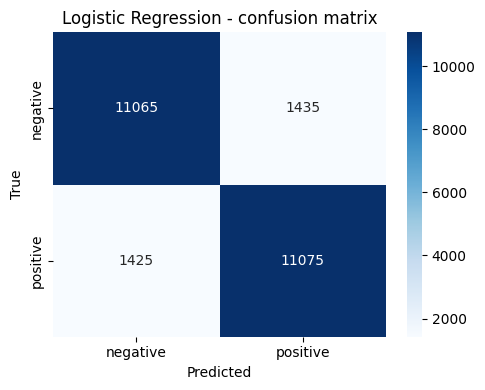

In [42]:
df_train["text_clean"] = df_train["text"].apply(clean_full)
df_train["text_clean"] = df_train["text_clean"].astype(str)

df_test["text_clean"] = df_test["text"].apply(clean_full)
df_test["text_clean"] = df_test["text_clean"].astype(str)

X_train = df_train["text_clean"]
y_train = df_train["sentiment_label"]
X_test = df_test["text_clean"]
y_test = df_test["sentiment_label"]

lr_clf = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)),
        ("clf", LogisticRegression(max_iter=2000)),
    ]
)

with mlflow.start_run(run_name="logreg_tfidf_text_clean") as active_run:
    LR_RUN_ID = active_run.info.run_id

    lr_clf.fit(X_train, y_train)
    y_pred_lr = lr_clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred_lr)
    cm = confusion_matrix(y_test, y_pred_lr)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_lr, average="binary", pos_label=1
    )

    mlflow.log_param("input_column",   "text_clean")
    mlflow.log_param("split_strategy", "imdb_official_25k_25k")
    mlflow.log_param("train_size",     len(X_train))
    mlflow.log_param("test_size",      len(X_test))

    mlflow.log_metric("test_accuracy",      acc)
    mlflow.log_metric("test_precision_pos", prec)
    mlflow.log_metric("test_recall_pos",    rec)
    mlflow.log_metric("test_f1_pos",        f1)

    print(f"Run ID: {LR_RUN_ID}")
    print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision (pos): {prec:.4f} | Recall (pos): {rec:.4f} | F1 (pos): {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred_lr, target_names=["negative", "positive"]))
    print("Confusion matrix [[TN FP],[FN TP]]:")
    print(cm)

    example = X_test.iloc[0]
    print("\nExample text_clean (first 200 chars):")
    print(example[:200] + ("..." if len(example) > 200 else ""))
    print("Predicted:", "positive" if lr_clf.predict([example])[0] == 1 else "negative")

    # Confusion matrix → artefakt MLflow
    fig_cm, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "positive"],
        yticklabels=["negative", "positive"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Logistic Regression - confusion matrix")
    fig_cm.tight_layout()
    mlflow.log_figure(fig_cm, "confusion_matrix.png")
    plt.show()

Top features for positive class (highest coefficients):
  'great'	7.818
  'excellent'	6.255
  'best'	5.025
  'wonderful'	4.846
  'perfect'	4.793
  'well'	4.643
  'love'	4.439
  'amazing'	4.283
  'favorite'	4.216
  'loved'	3.998
  'fun'	3.994
  'today'	3.562
  'also'	3.535
  'life'	3.531
  'beautiful'	3.485
  'enjoyed'	3.477
  'brilliant'	3.473
  'one best'	3.348
  'still'	3.271
  'highly'	3.262

Top features for negative class (lowest coefficients):
  'bad'	-8.672
  'worst'	-8.604
  'awful'	-6.460
  'boring'	-5.840
  'waste'	-5.679
  'no'	-5.498
  'poor'	-5.396
  'nothing'	-5.182
  'not'	-4.977
  'terrible'	-4.888
  'worse'	-4.561
  'horrible'	-4.234
  'stupid'	-4.167
  'script'	-4.067
  'dull'	-4.054
  'poorly'	-3.886
  'unfortunately'	-3.851
  'minute'	-3.829
  'supposed'	-3.764
  'not even'	-3.750


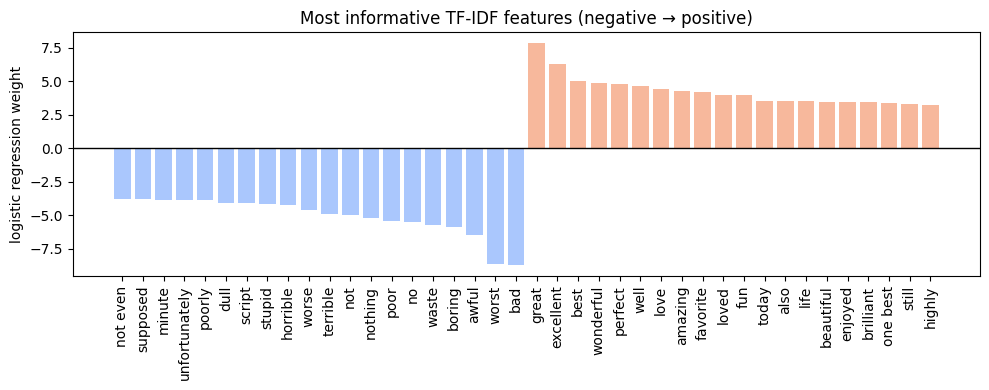


✓ Feature artifacts dopięte do runa 4f8257b3ad2543f9b802831f1fdeae42


In [45]:
with mlflow.start_run(run_id=LR_RUN_ID):
    vectorizer = lr_clf.named_steps["tfidf"]
    model = lr_clf.named_steps["clf"]
    feature_names = vectorizer.get_feature_names_out()
    coef = model.coef_[0]

    top_k = 20
    pos_idx = coef.argsort()[-top_k:][::-1]
    neg_idx = coef.argsort()[:top_k]

    print("Top features for positive class (highest coefficients):")
    for i in pos_idx:
        print(f"  {feature_names[i]!r}\t{coef[i]:.3f}")

    print("\nTop features for negative class (lowest coefficients):")
    for i in neg_idx:
        print(f"  {feature_names[i]!r}\t{coef[i]:.3f}")

    fig_feat, ax = plt.subplots(figsize=(10, 4))
    terms = [feature_names[i] for i in list(neg_idx[::-1]) + list(pos_idx)]
    weights = [coef[i] for i in list(neg_idx[::-1]) + list(pos_idx)]
    colors = [(0.6673, 0.7792, 0.9930)] * top_k + [(0.9682, 0.7208, 0.6123)] * top_k
    ax.bar(range(len(weights)), weights, color=colors)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(range(len(weights)))
    ax.set_xticklabels(terms, rotation=90)
    ax.set_ylabel("logistic regression weight")
    ax.set_title("Most informative TF-IDF features (negative → positive)")
    fig_feat.tight_layout()
    mlflow.log_figure(fig_feat, "top_features.png")
    plt.show()

    lines = ["Top positive features:"]
    lines += [f"  {feature_names[i]:<25s} {coef[i]:+.3f}" for i in pos_idx]
    lines += ["", "Top negative features:"]
    lines += [f"  {feature_names[i]:<25s} {coef[i]:+.3f}" for i in neg_idx]
    mlflow.log_text("\n".join(lines), "top_features.txt")

    print(f"\n✓ Feature artifacts dopięte do runa {LR_RUN_ID}")

---
to be announced...